Cell 1:

In [1]:
!nvidia-smi


Tue Apr  7 08:18:58 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 566.14                 Driver Version: 566.14         CUDA Version: 12.7     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                  Driver-Model | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce GTX 1650      WDDM  |   00000000:01:00.0 Off |                  N/A |
| N/A   58C    P8             10W /   65W |      98MiB /   4096MiB |     24%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
!nvidia-smi -l 1

^C


Cell 2

In [5]:
# ── Cell 1: Imports & Device ──────────────────────────────────────────────────
import os, random, warnings
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.models as models
import torchvision.transforms as T
from torch.utils.data import Dataset, DataLoader
from PIL import Image
from sklearn.metrics import accuracy_score, classification_report
import matplotlib.pyplot as plt

warnings.filterwarnings('ignore')

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')
if torch.cuda.is_available():
    print(f'GPU   : {torch.cuda.get_device_name(0)}')

Device: cuda
GPU   : NVIDIA GeForce GTX 1650


Cell 3

In [6]:
# ── Cell 2: Config ────────────────────────────────────────────────────────────
TRAIN_DIR  = r'D:\yolov26\dataset_classification\Training'
VAL_DIR    = r'D:\yolov26\dataset_classification\Testing'
SAVE_PATH  = 'best_classification.pth'

IMG_SIZE   = 224
BATCH_SIZE = 32


# Kiểm tra dataset
assert os.path.exists(TRAIN_DIR), f'Không tìm thấy: {TRAIN_DIR}'
assert os.path.exists(VAL_DIR),   f'Không tìm thấy: {VAL_DIR}'

classes = sorted(os.listdir(TRAIN_DIR))
NUM_CLASSES = len(classes)
print(f'Classes ({NUM_CLASSES}): {classes}')

# Đếm ảnh
for split, d in [('Train', TRAIN_DIR), ('Val', VAL_DIR)]:
    counts = {c: len(os.listdir(os.path.join(d, c))) for c in classes}
    print(f'{split}: {counts}  | total={sum(counts.values())}')

Classes (4): ['glioma', 'meningioma', 'notumor', 'pituitary']
Train: {'glioma': 1400, 'meningioma': 1386, 'notumor': 1281, 'pituitary': 1362}  | total=5429
Val: {'glioma': 386, 'meningioma': 398, 'notumor': 400, 'pituitary': 400}  | total=1584


Cell 4:

In [7]:
MEAN = (0.485, 0.456, 0.406)
STD  = (0.229, 0.224, 0.225)

train_transform = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.RandomHorizontalFlip(p=0.5),
    T.RandomRotation(degrees=15),
    T.ColorJitter(brightness=0.2, contrast=0.2),
    T.ToTensor(),
    T.Normalize(MEAN, STD),
])

val_transform = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.ToTensor(),
    T.Normalize(MEAN, STD),
])

class BrainTumorDataset(Dataset):
    VALID_EXT = ('.jpg', '.jpeg', '.png', '.bmp')

    def __init__(self, root_dir, transform=None):
        self.transform = transform
        self.classes   = sorted(os.listdir(root_dir))
        self.cls2idx   = {c: i for i, c in enumerate(self.classes)}
        self.samples   = []  # list of (path, label)

        for cls in self.classes:
            cls_dir = os.path.join(root_dir, cls)
            for f in os.listdir(cls_dir):
                if f.lower().endswith(self.VALID_EXT):
                    self.samples.append((os.path.join(cls_dir, f), self.cls2idx[cls]))

        print(f'Loaded {len(self.samples)} images from {root_dir}')

    def __len__(self): return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        img = Image.open(path).convert('RGB')
        if self.transform:
            img = self.transform(img)
        return img, label


Cell 5

In [8]:
train_ds = BrainTumorDataset(TRAIN_DIR, transform=train_transform)
val_ds   = BrainTumorDataset(VAL_DIR,   transform=val_transform)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)

Loaded 5429 images from D:\yolov26\dataset_classification\Training
Loaded 1584 images from D:\yolov26\dataset_classification\Testing


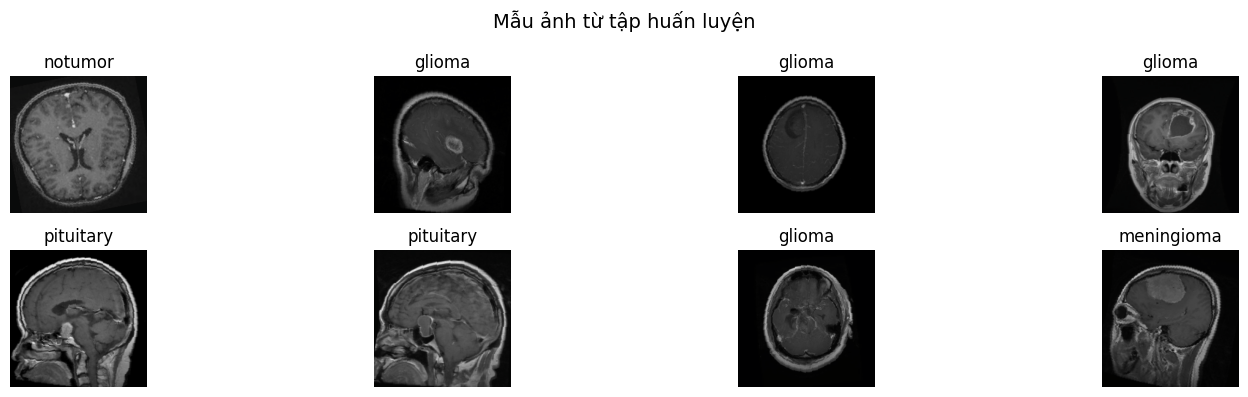

In [9]:
import matplotlib.pyplot as plt
import numpy as np

def imshow(tensor, title=None):
    img = tensor.numpy().transpose((1, 2, 0))
    img = STD * img + MEAN          # Denormalize
    img = np.clip(img, 0, 1)
    plt.imshow(img)
    if title: plt.title(title)
    plt.axis('off')

# Lấy 1 batch mẫu
images, labels = next(iter(train_loader))

plt.figure(figsize=(16, 4))
for i in range(8):
    plt.subplot(2, 4, i+1)
    imshow(images[i], title=train_ds.classes[labels[i]])
plt.suptitle('Mẫu ảnh từ tập huấn luyện', fontsize=14)
plt.tight_layout()
plt.show()

Cell 6

In [7]:
model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)

Cell 7

In [8]:
in_features = model.fc.in_features  # 2048
model.fc = nn.Sequential(
    nn.Dropout(p=0.5),
    nn.Linear(in_features, NUM_CLASSES)
)

model = model.to(DEVICE)
print(f'Model: ResNet50 pretrained | fc input={in_features} → {NUM_CLASSES} classes')
total_params   = sum(p.numel() for p in model.parameters())
trainable_init = sum(p.numel() for p in model.fc.parameters())
print(f'Total params : {total_params:,}')
print(f'fc params    : {trainable_init:,}')

Model: ResNet50 pretrained | fc input=2048 → 4 classes
Total params : 23,516,228
fc params    : 8,196


Cell 8

In [8]:
import torch.optim as optim
from sklearn.metrics import accuracy_score

# 1. Các hàm hỗ trợ
def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss = 0
    for imgs, labels in loader:
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        loss = criterion(model(imgs), labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(loader)

@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()
    total_loss, preds_all, labels_all = 0, [], []
    for imgs, labels in loader:
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        out = model(imgs)
        total_loss += criterion(out, labels).item()
        preds_all.extend(torch.argmax(out, 1).cpu().numpy())
        labels_all.extend(labels.cpu().numpy())
    avg_loss = total_loss / len(loader)
    acc = accuracy_score(labels_all, preds_all)
    return avg_loss, acc

# 2. Khởi tạo các biến theo dõi
criterion = nn.CrossEntropyLoss()
history = {'train_loss': [], 'val_loss': [], 'val_acc': []}
best_val_loss = float('inf')
patience_cnt = 0

print("✅ Đã chuẩn bị xong hàm và cấu hình. Sẵn sàng training.")

✅ Đã chuẩn bị xong hàm và cấu hình. Sẵn sàng training.


Lần 1

Cell 9.1

In [9]:
# ── Phase 1: Freeze backbone, chỉ train fc (warm-up) ────────────────────────
for param in model.parameters():
    param.requires_grad = False
for param in model.fc.parameters():
    param.requires_grad = True

optimizer = optim.Adam(model.fc.parameters(), lr=LR_HEAD)
print(f'Phase 1 — Warm-up {PHASE1_EP} epochs (backbone frozen, lr={LR_HEAD})')

for epoch in range(1, PHASE1_EP + 1):
    tr_loss = train_one_epoch(model, train_loader, optimizer, criterion)
    val_loss, val_acc = evaluate(model, val_loader, criterion)
    history['train_loss'].append(tr_loss)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)
    print(f'  [{epoch:02d}/{PHASE1_EP}] Train={tr_loss:.4f} | Val={val_loss:.4f} | Acc={val_acc:.4f}')

# ── Phase 2: Unfreeze toàn bộ, fine-tune với LR thấp ─────────────────────────
for param in model.parameters():
    param.requires_grad = True

optimizer = optim.Adam(model.parameters(), lr=LR_FULL)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)

print(f'\nPhase 2 — Fine-tune toàn bộ (lr={LR_FULL}, max {EPOCHS} epochs, patience={PATIENCE})')

for epoch in range(1, EPOCHS + 1):
    tr_loss = train_one_epoch(model, train_loader, optimizer, criterion)
    val_loss, val_acc = evaluate(model, val_loader, criterion)

    history['train_loss'].append(tr_loss)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)
    scheduler.step(val_loss)

    saved = ''
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_cnt = 0
        torch.save(model.state_dict(), SAVE_PATH)
        saved = ' ← saved'
    else:
        patience_cnt += 1

    print(f'  [{epoch:02d}/{EPOCHS}] Train={tr_loss:.4f} | Val={val_loss:.4f} | Acc={val_acc:.4f}{saved}')

    if patience_cnt >= PATIENCE:
        print(f'Early stopping tại epoch {epoch + PHASE1_EP}')
        break

print(f'\nBest val loss: {best_val_loss:.4f}')

Phase 1 — Warm-up 5 epochs (backbone frozen, lr=0.001)
  [01/5] Train=0.7372 | Val=0.5847 | Acc=0.7936
  [02/5] Train=0.5331 | Val=0.6498 | Acc=0.7475
  [03/5] Train=0.5046 | Val=0.5253 | Acc=0.8176
  [04/5] Train=0.4960 | Val=0.5947 | Acc=0.7790
  [05/5] Train=0.4721 | Val=0.5657 | Acc=0.8043

Phase 2 — Fine-tune toàn bộ (lr=1e-05, max 30 epochs, patience=7)
  [01/30] Train=0.3322 | Val=0.3636 | Acc=0.8889 ← saved
  [02/30] Train=0.1908 | Val=0.3514 | Acc=0.9104 ← saved
  [03/30] Train=0.1280 | Val=0.3094 | Acc=0.9287 ← saved
  [04/30] Train=0.0981 | Val=0.3070 | Acc=0.9381 ← saved
  [05/30] Train=0.0757 | Val=0.3281 | Acc=0.9419
  [06/30] Train=0.0627 | Val=0.2731 | Acc=0.9508 ← saved
  [07/30] Train=0.0485 | Val=0.2749 | Acc=0.9577
  [08/30] Train=0.0341 | Val=0.3502 | Acc=0.9508
  [09/30] Train=0.0357 | Val=0.3008 | Acc=0.9545
  [10/30] Train=0.0307 | Val=0.3521 | Acc=0.9533
  [11/30] Train=0.0263 | Val=0.3486 | Acc=0.9552
  [12/30] Train=0.0255 | Val=0.3238 | Acc=0.9564
  [13/30] 

In [11]:
!pip install seaborn

Cell  10.1

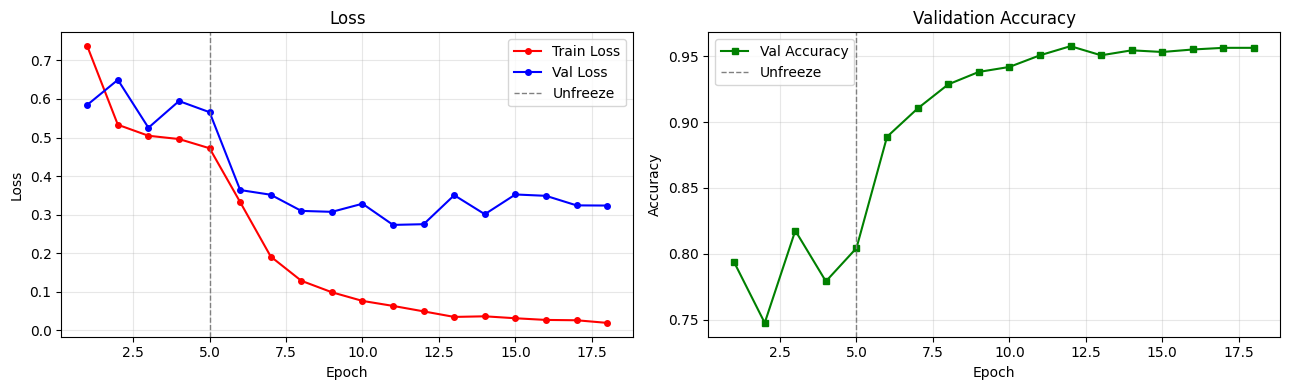

Best Val Acc  : 0.9577
Best Val Loss : 0.2731


In [17]:
# ── Cell 6: Vẽ biểu đồ Loss & Accuracy ───────────────────────────────────────
epochs_range = range(1, len(history['train_loss']) + 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

ax1.plot(epochs_range, history['train_loss'], 'r-o', markersize=4, label='Train Loss')
ax1.plot(epochs_range, history['val_loss'],   'b-o', markersize=4, label='Val Loss')
ax1.axvline(PHASE1_EP, color='gray', linestyle='--', linewidth=1, label='Unfreeze')
ax1.set(title='Loss', xlabel='Epoch', ylabel='Loss')
ax1.legend(); ax1.grid(True, alpha=0.3)

ax2.plot(epochs_range, history['val_acc'], 'g-s', markersize=4, label='Val Accuracy')
ax2.axvline(PHASE1_EP, color='gray', linestyle='--', linewidth=1, label='Unfreeze')
ax2.set(title='Validation Accuracy', xlabel='Epoch', ylabel='Accuracy')
ax2.legend(); ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
print(f'Best Val Acc  : {max(history["val_acc"]):.4f}')
print(f'Best Val Loss : {min(history["val_loss"]):.4f}')

Cell 11.1

In [18]:
# ── Cell 7: Evaluation Chi Tiết (Classification Report) ──────────────────────
# Load best model
model.load_state_dict(torch.load(SAVE_PATH, map_location=DEVICE))
model.eval()

all_preds, all_labels = [], []
with torch.no_grad():
    for imgs, labels in val_loader:
        out = model(imgs.to(DEVICE))
        all_preds.extend(torch.argmax(out, 1).cpu().numpy())
        all_labels.extend(labels.numpy())

print('Classification Report:')
print(classification_report(all_labels, all_preds, target_names=classes, digits=4))

Classification Report:
              precision    recall  f1-score   support

      glioma     0.9846    0.8264    0.8986       386
  meningioma     0.8929    0.9849    0.9367       398
     notumor     0.9455    0.9975    0.9708       400
   pituitary     0.9925    0.9900    0.9912       400

    accuracy                         0.9508      1584
   macro avg     0.9539    0.9497    0.9493      1584
weighted avg     0.9537    0.9508    0.9498      1584



Cell 12.1

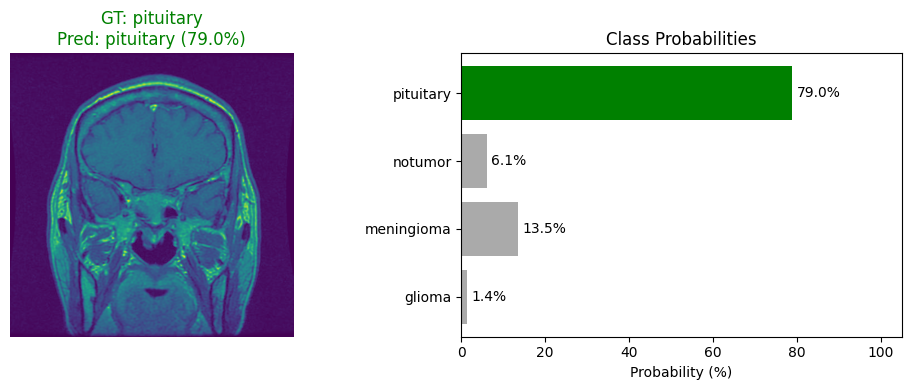

In [19]:
# ── Cell 8: Inference Demo (random ảnh từ Val set) ───────────────────────────
import torch.nn.functional as F

# Load best model (nếu chưa load ở cell trên)
model.load_state_dict(torch.load(SAVE_PATH, map_location=DEVICE))
model.eval()

def predict(img_path):
    img = Image.open(img_path).convert('RGB')
    tensor = val_transform(img).unsqueeze(0).to(DEVICE)
    with torch.no_grad():
        probs = F.softmax(model(tensor), dim=1)[0]
    conf, idx = probs.max(0)
    return classes[idx.item()], conf.item(), probs.cpu().numpy()


# Random chọn 1 ảnh
rand_cls  = random.choice(classes)
cls_dir   = os.path.join(VAL_DIR, rand_cls)
rand_img  = random.choice([f for f in os.listdir(cls_dir) if f.lower().endswith(('.jpg', '.jpeg', '.png'))])
img_path  = os.path.join(cls_dir, rand_img)

pred_cls, confidence, probs = predict(img_path)
correct = (pred_cls == rand_cls)

# Hiển thị
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

ax1.imshow(Image.open(img_path))
color = 'green' if correct else 'red'
ax1.set_title(f'GT: {rand_cls}\nPred: {pred_cls} ({confidence*100:.1f}%)', color=color, fontsize=12)
ax1.axis('off')

bars = ax2.barh(classes, probs * 100, color=['green' if c == pred_cls else '#aaa' for c in classes])
ax2.set_xlabel('Probability (%)')
ax2.set_xlim(0, 105)
for bar, p in zip(bars, probs):
    ax2.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
             f'{p*100:.1f}%', va='center', fontsize=10)
ax2.set_title('Class Probabilities')

plt.tight_layout()
plt.show()

Cell 13.1

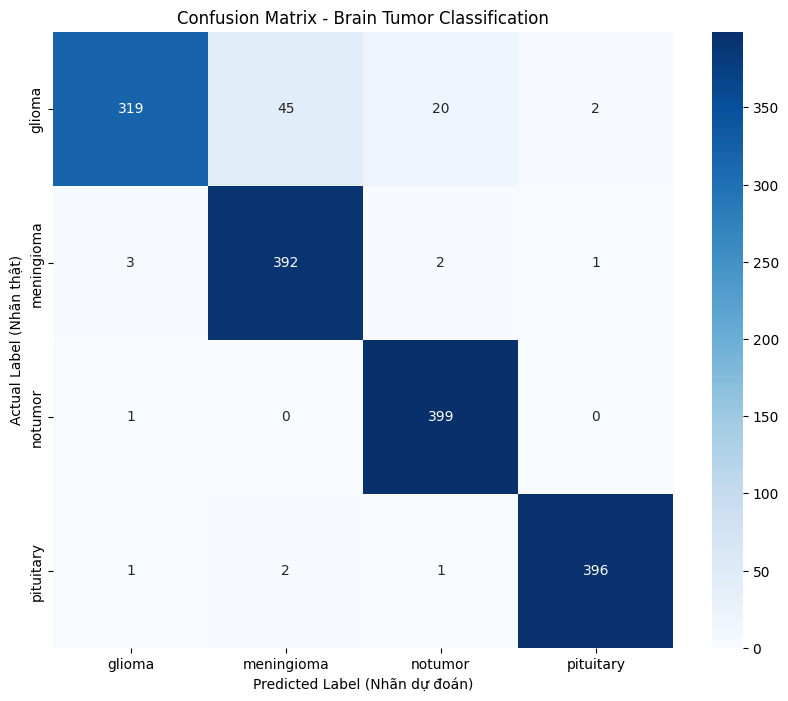

Số lượng mẫu cụ thể trên từng ô:
[[319  45  20   2]
 [  3 392   2   1]
 [  1   0 399   0]
 [  1   2   1 396]]


In [16]:
# ── Cell 9: Ma trận nhầm lẫn (Confusion Matrix) ──────────────────────────────
import seaborn as sns
from sklearn.metrics import confusion_matrix

# 1. Load trọng số tốt nhất và dự đoán trên tập Validation
model.load_state_dict(torch.load(SAVE_PATH, map_location=DEVICE))
model.eval()

y_true = []
y_pred = []

with torch.no_grad():
    for imgs, labels in val_loader:
        imgs = imgs.to(DEVICE)
        outputs = model(imgs)
        preds = torch.argmax(outputs, dim=1)
        
        y_true.extend(labels.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())

# 2. Tạo ma trận nhầm lẫn
cm = confusion_matrix(y_true, y_pred)

# 3. Vẽ biểu đồ
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=classes, yticklabels=classes)

plt.title('Confusion Matrix - Brain Tumor Classification')
plt.ylabel('Actual Label (Nhãn thật)')
plt.xlabel('Predicted Label (Nhãn dự đoán)')
plt.show()

# In ra số lượng cụ thể nếu cần soi kỹ
print("Số lượng mẫu cụ thể trên từng ô:")
print(cm)

Lần 2

In [ ]:
EPOCHS     = 30
PATIENCE   = 7
LR_HEAD    = 1e-3
LR_FULL    = 1e-5
PHASE1_EP  = 5

In [9]:
# ── Cell 2: Config (Tối ưu cho GPU 4GB & Độ chính xác cao) ────────────────────
IMG_SIZE   = 224
BATCH_SIZE = 16        # Giảm từ 32 -> 16 để tiết kiệm VRAM và tăng tính tổng quát
EPOCHS     = 100       # Tăng mạnh số Epoch, Early Stopping sẽ lo việc dừng khi hội tụ
PATIENCE   = 15        # Tăng lên 15 để model có không gian "thử sai" khi LR thấp
LR_HEAD    = 5e-4      # Phase 1: Giảm một nửa để lớp FC học ổn định hơn
LR_FULL    = 5e-6      # Phase 2: LR cực nhỏ để fine-tune sâu mà không phá hỏng weights
PHASE1_EP  = 10        # Tăng warm-up để "nền móng" FC vững chắc trước khi unfreeze

In [13]:
# ── Cell Định Nghĩa Hàm (CHẠY CELL NÀY TRƯỚC) ─────────────────────────────────
from sklearn.metrics import accuracy_score
import torch.nn as nn
import torch

def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss = 0
    for imgs, labels in loader:
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        loss = criterion(model(imgs), labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(loader)

@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()
    total_loss, preds_all, labels_all = 0, [], []
    for imgs, labels in loader:
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        out = model(imgs)
        total_loss += criterion(out, labels).item()
        preds_all.extend(torch.argmax(out, 1).cpu().numpy())
        labels_all.extend(labels.cpu().numpy())
    avg_loss = total_loss / len(loader)
    acc = accuracy_score(labels_all, preds_all)
    return avg_loss, acc

# Khởi tạo các biến môi trường cho vòng lặp
criterion = nn.CrossEntropyLoss()
history = {'train_loss': [], 'val_loss': [], 'val_acc': []}
best_val_loss = float('inf')
patience_cnt = 0

print("✅ Đã nạp hàm 'train_one_epoch' và 'evaluate' vào bộ nhớ thành công!")

✅ Đã nạp hàm 'train_one_epoch' và 'evaluate' vào bộ nhớ thành công!


In [ ]:
# ── Phase 1: Freeze backbone, chỉ train fc (warm-up) ────────────────────────
for param in model.parameters():
    param.requires_grad = False
for param in model.fc.parameters():
    param.requires_grad = True

optimizer = optim.Adam(model.fc.parameters(), lr=LR_HEAD)
print(f'Phase 1 — Warm-up {PHASE1_EP} epochs (backbone frozen, lr={LR_HEAD})')

for epoch in range(1, PHASE1_EP + 1):
    tr_loss = train_one_epoch(model, train_loader, optimizer, criterion)
    val_loss, val_acc = evaluate(model, val_loader, criterion)
    history['train_loss'].append(tr_loss)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)
    print(f'  [{epoch:02d}/{PHASE1_EP}] Train={tr_loss:.4f} | Val={val_loss:.4f} | Acc={val_acc:.4f}')

# ── Phase 2: Unfreeze toàn bộ, fine-tune với LR thấp ─────────────────────────
for param in model.parameters():
    param.requires_grad = True

optimizer = optim.Adam(model.parameters(), lr=LR_FULL)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)

print(f'\nPhase 2 — Fine-tune toàn bộ (lr={LR_FULL}, max {EPOCHS} epochs, patience={PATIENCE})')

for epoch in range(1, EPOCHS + 1):
    tr_loss = train_one_epoch(model, train_loader, optimizer, criterion)
    val_loss, val_acc = evaluate(model, val_loader, criterion)

    history['train_loss'].append(tr_loss)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)
    scheduler.step(val_loss)

    saved = ''
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_cnt = 0
        torch.save(model.state_dict(), SAVE_PATH)
        saved = ' ← saved'
    else:
        patience_cnt += 1

    print(f'  [{epoch:02d}/{EPOCHS}] Train={tr_loss:.4f} | Val={val_loss:.4f} | Acc={val_acc:.4f}{saved}')

    if patience_cnt >= PATIENCE:
        print(f'Early stopping tại epoch {epoch + PHASE1_EP}')
        break

print(f'\nBest val loss: {best_val_loss:.4f}')

Phase 1 — Warm-up 10 epochs (backbone frozen, lr=0.0005)
  [01/10] Train=0.8451 | Val=0.7151 | Acc=0.7487
  [02/10] Train=0.5779 | Val=0.5838 | Acc=0.7923
  [03/10] Train=0.5228 | Val=0.5519 | Acc=0.8018
  [04/10] Train=0.5097 | Val=0.5869 | Acc=0.7885
  [05/10] Train=0.4783 | Val=0.5264 | Acc=0.8163
  [06/10] Train=0.4553 | Val=0.5412 | Acc=0.8188
  [07/10] Train=0.4619 | Val=0.5438 | Acc=0.8150
  [08/10] Train=0.4715 | Val=0.5902 | Acc=0.7910
  [09/10] Train=0.4506 | Val=0.5124 | Acc=0.8239
  [10/10] Train=0.4484 | Val=0.4976 | Acc=0.8302

Phase 2 — Fine-tune toàn bộ (lr=5e-06, max 100 epochs, patience=15)
  [01/100] Train=0.3663 | Val=0.4590 | Acc=0.8567 ← saved
  [02/100] Train=0.2562 | Val=0.3830 | Acc=0.8870 ← saved
  [03/100] Train=0.2006 | Val=0.3455 | Acc=0.9066 ← saved
  [04/100] Train=0.1605 | Val=0.3157 | Acc=0.9223 ← saved
  [05/100] Train=0.1306 | Val=0.3245 | Acc=0.9230
  [06/100] Train=0.1177 | Val=0.3361 | Acc=0.9242
  [07/100] Train=0.0984 | Val=0.3109 | Acc=0.9343 ← 

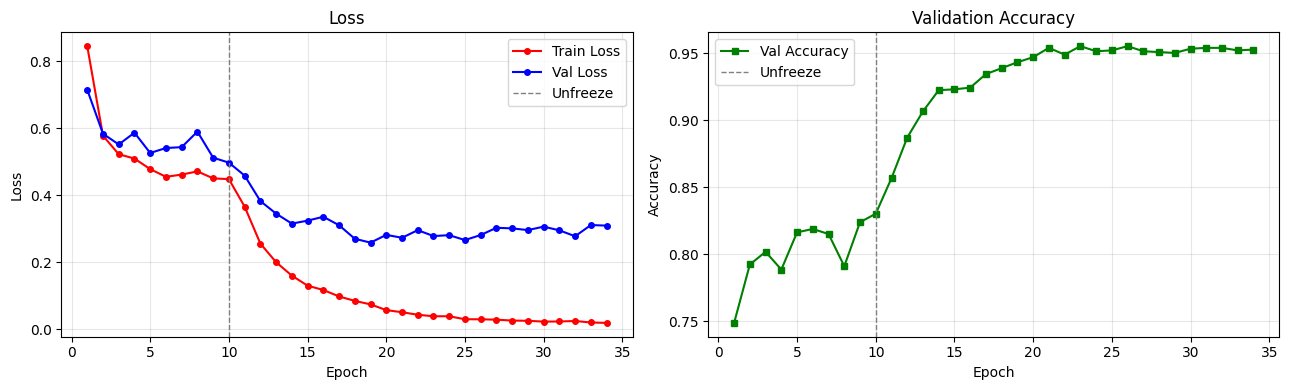

Best Val Acc  : 0.9552
Best Val Loss : 0.2589


In [15]:
# ── Cell 6: Vẽ biểu đồ Loss & Accuracy ───────────────────────────────────────
epochs_range = range(1, len(history['train_loss']) + 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

ax1.plot(epochs_range, history['train_loss'], 'r-o', markersize=4, label='Train Loss')
ax1.plot(epochs_range, history['val_loss'],   'b-o', markersize=4, label='Val Loss')
ax1.axvline(PHASE1_EP, color='gray', linestyle='--', linewidth=1, label='Unfreeze')
ax1.set(title='Loss', xlabel='Epoch', ylabel='Loss')
ax1.legend(); ax1.grid(True, alpha=0.3)

ax2.plot(epochs_range, history['val_acc'], 'g-s', markersize=4, label='Val Accuracy')
ax2.axvline(PHASE1_EP, color='gray', linestyle='--', linewidth=1, label='Unfreeze')
ax2.set(title='Validation Accuracy', xlabel='Epoch', ylabel='Accuracy')
ax2.legend(); ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
print(f'Best Val Acc  : {max(history["val_acc"]):.4f}')
print(f'Best Val Loss : {min(history["val_loss"]):.4f}')

In [16]:
# ── Cell 7: Evaluation Chi Tiết (Classification Report) ──────────────────────
# Load best model
model.load_state_dict(torch.load(SAVE_PATH, map_location=DEVICE))
model.eval()

all_preds, all_labels = [], []
with torch.no_grad():
    for imgs, labels in val_loader:
        out = model(imgs.to(DEVICE))
        all_preds.extend(torch.argmax(out, 1).cpu().numpy())
        all_labels.extend(labels.numpy())

print('Classification Report:')
print(classification_report(all_labels, all_preds, target_names=classes, digits=4))

Classification Report:
              precision    recall  f1-score   support

      glioma     0.9844    0.8187    0.8939       386
  meningioma     0.8974    0.9673    0.9311       398
     notumor     0.9149    0.9950    0.9533       400
   pituitary     0.9900    0.9875    0.9887       400

    accuracy                         0.9432      1584
   macro avg     0.9467    0.9421    0.9418      1584
weighted avg     0.9464    0.9432    0.9422      1584



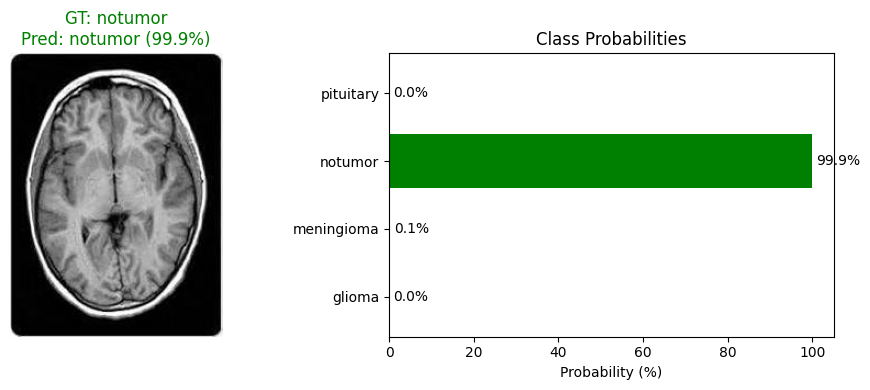

In [18]:
# ── Cell 8: Inference Demo (random ảnh từ Val set) ───────────────────────────
import torch.nn.functional as F

# Load best model (nếu chưa load ở cell trên)
model.load_state_dict(torch.load(SAVE_PATH, map_location=DEVICE))
model.eval()

def predict(img_path):
    img = Image.open(img_path).convert('RGB')
    tensor = val_transform(img).unsqueeze(0).to(DEVICE)
    with torch.no_grad():
        probs = F.softmax(model(tensor), dim=1)[0]
    conf, idx = probs.max(0)
    return classes[idx.item()], conf.item(), probs.cpu().numpy()


# Random chọn 1 ảnh
rand_cls  = random.choice(classes)
cls_dir   = os.path.join(VAL_DIR, rand_cls)
rand_img  = random.choice([f for f in os.listdir(cls_dir) if f.lower().endswith(('.jpg', '.jpeg', '.png'))])
img_path  = os.path.join(cls_dir, rand_img)

pred_cls, confidence, probs = predict(img_path)
correct = (pred_cls == rand_cls)

# Hiển thị
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

ax1.imshow(Image.open(img_path))
color = 'green' if correct else 'red'
ax1.set_title(f'GT: {rand_cls}\nPred: {pred_cls} ({confidence*100:.1f}%)', color=color, fontsize=12)
ax1.axis('off')

bars = ax2.barh(classes, probs * 100, color=['green' if c == pred_cls else '#aaa' for c in classes])
ax2.set_xlabel('Probability (%)')
ax2.set_xlim(0, 105)
for bar, p in zip(bars, probs):
    ax2.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
             f'{p*100:.1f}%', va='center', fontsize=10)
ax2.set_title('Class Probabilities')

plt.tight_layout()
plt.show()

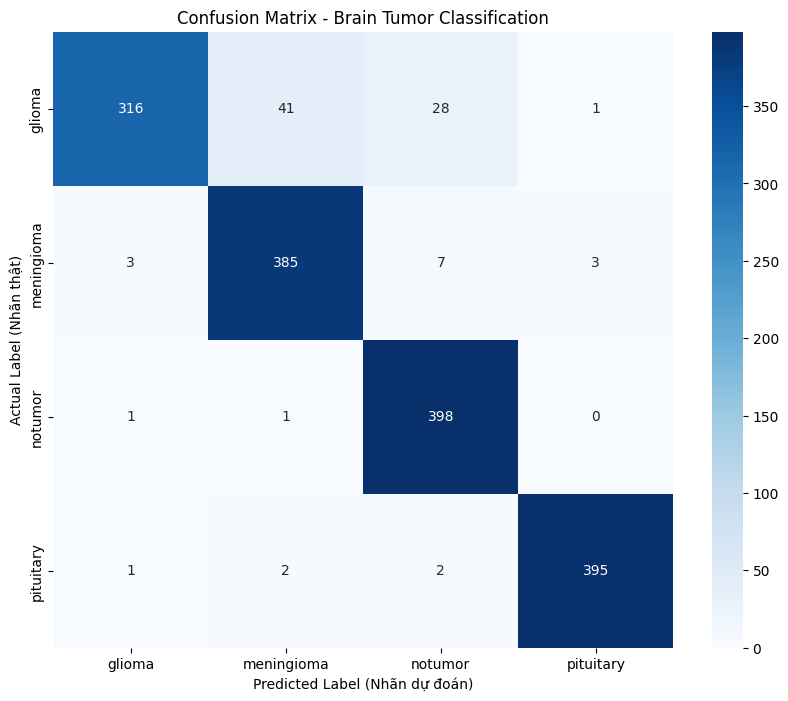

Số lượng mẫu cụ thể trên từng ô:
[[316  41  28   1]
 [  3 385   7   3]
 [  1   1 398   0]
 [  1   2   2 395]]


In [17]:
# ── Cell 9: Ma trận nhầm lẫn (Confusion Matrix) ──────────────────────────────
import seaborn as sns
from sklearn.metrics import confusion_matrix

# 1. Load trọng số tốt nhất và dự đoán trên tập Validation
model.load_state_dict(torch.load(SAVE_PATH, map_location=DEVICE))
model.eval()

y_true = []
y_pred = []

with torch.no_grad():
    for imgs, labels in val_loader:
        imgs = imgs.to(DEVICE)
        outputs = model(imgs)
        preds = torch.argmax(outputs, dim=1)
        
        y_true.extend(labels.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())

# 2. Tạo ma trận nhầm lẫn
cm = confusion_matrix(y_true, y_pred)

# 3. Vẽ biểu đồ
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=classes, yticklabels=classes)

plt.title('Confusion Matrix - Brain Tumor Classification')
plt.ylabel('Actual Label (Nhãn thật)')
plt.xlabel('Predicted Label (Nhãn dự đoán)')
plt.show()

# In ra số lượng cụ thể nếu cần soi kỹ
print("Số lượng mẫu cụ thể trên từng ô:")
print(cm)